Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you :
- Fill in your name
- Fill any place that says `YOUR CODE HERE` (you will be graded based on this code, any extra cells you code will not be graded)
- Delete  `NotImplementedError()` exception once you have completed your implementation

In [2]:
NAME = "NGUYEN THI THU TRANG"

# Problem 1: Linked List Fundamentals (4)

Give the appropriate answers for the questions below, **you only need 1-2 sentences for each question**.
1. Explain the concept of a Linked List.
2. How many distinct types of Linked Lists are there?
3. Detail the key distinctions between Linked Lists and Linear Arrays, outlining their respective advantages and drawbacks in a structured comparison.
4. Can you provide examples of applications that make use of Linked Lists?

ANSWER HERE (click here twice to answer)
1.	A Linked List is a data structure where each node contains data and a pointer to the next node, allowing efficient insertions and deletions.
2.	There are three main types: Singly Linked List, Doubly Linked List, and Circular Linked List.
3.	Linked Lists use dynamic memory allocation, allowing efficient insertions/deletions but slower access (O(n)), while Arrays use contiguous memory, enabling fast access (O(1)) but requiring resizing for insertions.
4.	Linked Lists are used in dynamic memory management, graph representations, text editors’ undo/redo features, and task scheduling in operating systems.

# Problem 2: Singly Linked List (2)

Implement a `Node` class and a `LinkedList` class storing multiple nodes. Each node maintains a reference to its element and one reference to the next node in the list.

* `__init__(self)`: Initialize an empty list.
* `__len__(self)`: Return the number of elements.
* `is_empty(self)`: Check if the list is empty.
* `__getitem__(self, k)`: Access data at position `k`.
* `insert(self, k, data)`: Insert a new node with data `data` at position `k`.
* `__delitem__(self, k)`: Delete the node at position `k`.
* `delete_by_value(self, val)`: Delete all nodes with value `val`. Return deleted values.
* `search(self, val)`: Find nodes with value `val`. Return position(s). Return `-1` and print("Not found") if `val` is not in list.
* `update(self, k, new_val)`: Update data at position `k`.
* `__str__(self)`: Return a string representation of the list.

In [3]:
class Node:
    def __init__(self, value, next_node=None):
        self.value = value
        self.next_node = next_node

In [4]:
class LinkedList:
    def __init__(self): # Initialize an empty list
        self.head = None
        self.size = 0
    
    def __len__(self): # Return the number of elements
        return self.size
    
    def is_empty(self): # Check if the list is empty
        return self.__len__ == 0
    
    def __getitem__(self, k): # Access data at position k
        if k < 0 or k >= self.size:
            raise IndexError("Index out of range")
            
        curr = self.head
        for _ in range(k):
            curr = curr.next_node
            
        return curr.value
    
    def insert(self, k, data): # Insert a new node with data at position k
        if k < 0 or k > self.size:
            raise IndexError("Index out of range")
        
        new_node = Node(data)
        if k == 0:
            new_node.next_node = self.head
            self.head = new_node
        else:
            curr = self.head
            for _ in range(k - 1):
                if curr is None:
                    raise IndexError("Index out of range")
                curr = curr.next_node
            new_node.next_node = curr.next_node
            curr.next_node = new_node
        
        self.size += 1

    def __delitem__(self, k): # Delete item at posion k
        if k < 0 or k >= self.size:
            raise IndexError("Index out of range")
        
        if k == 0:
            self.head = self.head.next_node
        else:
            curr = self.head
            for _ in range(k - 1):
                curr = curr.next_node
            curr.next_node = curr.next_node.next_node

        self.size -= 1
    
    # Delete all nodes with value val. Return deleted values.
    def delete_by_value(self, val): 
        pos = self.search(val)
        if pos == -1:
            print("Not found")
            return []
        
        for pos in sorted(pos, reverse=True):
            self.__delitem__(pos)


    # Find nodes with value `val`. Return position(s). 
    # Return `-1` and print("Not found") if `val` is not in list.
    def search(self, val):
        curr = self.head
        index = 0
        pos = []
        while curr:
            if curr.value == val:
                pos.append(index)
            curr = curr.next_node
            index += 1
        
        if not pos:
            print("Not found")
            return -1
        return pos

    def update(self, k, new_val): # Update data at posion k
        if k < 0 or k > self.size:
            raise IndexError("Index out of range")
        
        curr = self.head
        for _ in range(k):
            curr = curr.next_node
        
        curr.value = new_val
    
    def add_end(self, data):
        new_node = Node(data, None)
        
        if self.head is None:
            self.head = new_node
            return 
        
        curr = self.head
        while curr.next_node:
            curr = curr.next_node
        
        curr.next_node = new_node
                
    def __str__(self): # Return a string representation of the list.
        start = self.head
        elements = []
        while (start):
            elements.append(start.value)
            start = start.next_node

        elements.append(None)
        return ' -> '.join(map(str, elements))

In [5]:
ll = LinkedList()

# Test case 1: Insertion
ll.insert(0, 1)
ll.insert(1, 2)
ll.insert(2, 3)
ll.head.next_node.value

2

In [21]:
ll1 = LinkedList()
ll1.insert(0, 3)
ll1.insert(1, 3)
ll1.insert(2, 3)
ll1.insert(3, 1)
ll1.insert(4, 2)
ll1.delete_by_value(3)
print(str(ll1))


1 -> 2 -> None


In [7]:
# Initialize the linked list
ll = LinkedList()

# Test case 1: Insertion
ll.insert(0, 1)
ll.insert(1, 2)
ll.insert(2, 3)
assert len(ll) == 3
assert str(ll) == "1 -> 2 -> 3 -> None"

# Test case 2: Deletion by index
del ll[1]
assert len(ll) == 2
assert str(ll) == "1 -> 3 -> None"

# Test case 3: Deletion by value
ll.delete_by_value(3)
assert len(ll) == 1
assert str(ll) == "1 -> None"

# Test case 4: Search
assert ll.search(1) == [0]
ll.insert(1, 1)
assert ll.search(1) == [0, 1]
assert ll.search(2) == -1

# Test case 5: Update
ll.update(0, 10)
assert str(ll) == "10 -> 1 -> None"
assert ll[0] == 10

Not found


In [8]:
# Test case 6: Insertion at the beginning
ll.insert(0, 5)
assert str(ll) == "5 -> 10 -> 1 -> None"

# Test case 7: Insertion at the end
ll.insert(len(ll), 20)
assert str(ll) == "5 -> 10 -> 1 -> 20 -> None"

# Test case 8: Deletion of the last element
del ll[len(ll) - 1]
assert str(ll) == "5 -> 10 -> 1 -> None"

# Test case 9: Deletion of the only element
del ll[1]
del ll[0]
del ll[0]
assert str(ll) == "None"
assert len(ll) == 0

# Test case 10: Search in an empty list
assert ll.search(10) == -1

Not found


# Problem 3: Merge two Linked List at alternate positions (2)

You have two linked lists. Your task is to insert nodes from the second list (head2) into the first list (head1) at every alternate position. This means taking the first node of head2 and placing it after the first node of head1, then taking the next node from head2 and placing it after the second node of head1, and so on. If head2 is longer, the remaining nodes will be left unchanged in head2. If head1 is longer, the extra nodes will remain at the end of head1.

**Example:**
```
Input: head1: 1->2->3 , head2: 4->5->6->7->8
Output: head1: 1->4->2->5->3->6 , head2: 7->8
```
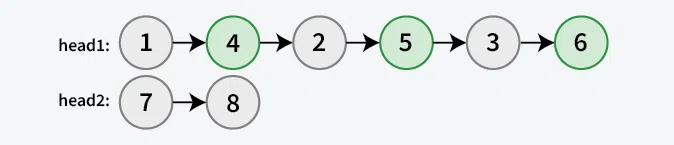

In [9]:
def merge_alternate(list1: LinkedList, list2: LinkedList):
    curr2 = list2.head
    index = 1

    while curr2 and index <= len(list1):
        list1.insert(index, curr2.value)
        curr2 = curr2.next_node
        index += 2
    
    remaining_list = LinkedList()
    while curr2:
        remaining_list.add_end(curr2.value)
        curr2 = curr2.next_node
    
    return list1, remaining_list if remaining_list.head else None


In [10]:
list1 = LinkedList()
list2 = LinkedList()

list1.insert(0, 2)
list1.insert(0, 1)

list2.insert(0, 6)
list2.insert(0, 5)
list2.insert(0, 4)
list2.insert(0, 3)

merged_list1, remaining_list2 = merge_alternate(list1, list2)

assert str(merged_list1) == "1 -> 3 -> 2 -> 4 -> None"
assert str(remaining_list2) == "5 -> 6 -> None"


In [11]:
list1 = LinkedList()
list2 = LinkedList()

list1.insert(0, 5)
list1.insert(0, 4)
list1.insert(0, 3)
list1.insert(0, 2)
list1.insert(0, 1)

list2.insert(0, 8)
list2.insert(0, 7)

merged_list1, remaining_list2 = merge_alternate(list1, list2)

assert str(merged_list1) == "1 -> 7 -> 2 -> 8 -> 3 -> 4 -> 5 -> None"
assert str(remaining_list2) == "None"

---
# Problem 4: Delete Nodes From Linked List Present in Array (2)

You are given an array of integers nums and the head of a linked list. Return the head of the modified linked list after removing all nodes from the linked list that have a value that exists in nums.



Example
```
Input: nums = [1,2,3], head = [1,2,3,4,5]
Output: [4,5]
```
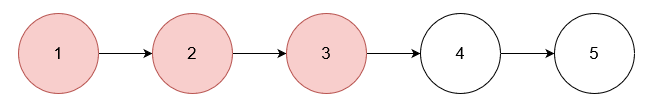

In [12]:
import random

In [13]:
def modifiedList(nums, ll: LinkedList):
    """
    :type nums: List[int]
    :type ll: LinkedList
    :rtype: LinkedList
    """
    while ll.head and ll.head.value in nums:
        ll.head = ll.head.next_node 

    curr = ll.head
    
    while curr and curr.next_node:
        if curr.next_node.value in nums:
            curr.next_node = curr.next_node.next_node  
        else:
            curr = curr.next_node  

    return ll  
    

In [14]:
ll = LinkedList()
ll.insert(0, 1)
ll.insert(1, 2)
ll.insert(2, 3)
ll.insert(3, 4)
ll.insert(4, 5)
assert str(modifiedList([1, 2, 3], ll)) == "4 -> 5 -> None"


In [15]:
ll = LinkedList()
ll.insert(0, 1)
ll.insert(1, 2)
ll.insert(2, 3)
ll.insert(3, 4)
ll.insert(4, 5)
assert str(modifiedList([1, 3], ll)) == "2 -> 4 -> 5 -> None"

In [16]:
# DO NOT DELETE THIS CELL

In [17]:
# DO NOT DELETE THIS CELL